Step 1: Import Libraries

Explanation:
•	Import libraries for data handling, preprocessing, and machine learning.
•	We use TF-IDF to convert text data into numerical format and K-means for clustering.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Step 2: Load and Inspect Data

Explanation:
•	Load the dataset and focus on the categories column.
•	Ensure the categories column contains valid data by dropping rows with missing or null values.

In [2]:
# Load the data
file_path = '../1429_1.csv'
data = pd.read_csv(file_path, delimiter=';')

# Keep only the 'categories' and 'reviews.text' columns for analysis
data = data[['categories', 'reviews.text']].dropna()

# Display the first few rows to inspect the data
print(data.head())

                                          categories  \
0  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
1  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
2  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
3  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
4  Electronics,iPad & Tablets,All Tablets,Fire Ta...   

                                        reviews.text  
0  This product so far has not disappointed. My c...  
1  great for beginner or experienced person. Boug...  
2  Inexpensive tablet for him to use and learn on...  
3  I've had my Fire HD 8 two weeks now and I love...  
4  I bought this for my grand daughter when she c...  


/var/folders/0v/2jlpljqd1msbtz5s_xyw4yj00000gn/T/ipykernel_96256/390414775.py:3: DtypeWarning: Columns (21,24,25,26,27,28,29,30,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path, delimiter=';')


In [3]:
data

,categories,reviews.text
0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",This product so far has not disappointed. My c...
1,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",great for beginner or experienced person. Boug...
2,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Inexpensive tablet for him to use and learn on...
3,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I've had my Fire HD 8 two weeks now and I love...
4,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I bought this for my grand daughter when she c...
...,...,...
41415,"Computers/Tablets & Networking,Tablet & eBook ...",This is not appreciably faster than any other ...
41416,"Computers/Tablets & Networking,Tablet & eBook ...",Amazon should include this charger with the Ki...
41417,"Computers/Tablets & Networking,Tablet & eBook ...",Love my Kindle Fire but I am really disappoint...
41418,"Computers/Tablets & Networking,Tablet & eBook ...",I was surprised to find it did not come with a...


Step 3: Preprocess the Categories

Explanation:
•	Clean the categories column by converting to lowercase and removing extra spaces.
•	This ensures consistency in the text data.

In [6]:
import pandas as pd
import re

# Preprocess the categories column
data['categories_cleaned'] = data['categories'].str.lower().str.strip()

# Step 1: Define a function to preprocess the categories column
def preprocess_categories(category):
    """
    Preprocess the categories column by cleaning empty rows, rows with numbers, gibberish, and special characters.

    Args:
    - category (str): Original category string.

    Returns:
    - str: Cleaned category string, or None if the category is invalid.
    """
    if pd.isnull(category) or category.strip() == "":
        return None  # Remove empty rows
    if category.strip().isdigit():
        return None  # Remove rows with just numbers
    if re.match(r'^[^a-zA-Z\s]+$', category.strip()):  # Remove gibberish (non-alphabetic text)
        return None
    # Remove special characters and keep only alphabetic words and spaces
    cleaned_category = re.sub(r'[^a-zA-Z\s]', ' ', category)
    return cleaned_category.strip() if cleaned_category.strip() else None

# Step 2: Apply the preprocessing function to the 'categories' column
data['categories_cleaned'] = data['categories'].apply(preprocess_categories)

# Step 3: Drop rows where 'categories_cleaned' is empty after preprocessing
data = data.dropna(subset=['categories_cleaned'])

# Step 4: Inspect the cleaned data
print("Cleaned Categories:")
print(data['categories_cleaned'].head())

Cleaned Categories:
0    Electronics iPad   Tablets All Tablets Fire Ta...
1    Electronics iPad   Tablets All Tablets Fire Ta...
2    Electronics iPad   Tablets All Tablets Fire Ta...
3    Electronics iPad   Tablets All Tablets Fire Ta...
4    Electronics iPad   Tablets All Tablets Fire Ta...
Name: categories_cleaned, dtype: object


Step 4: Convert Text Data to Numerical Format

Explanation:
•	Use TF-IDF Vectorizer to transform the cleaned categories column into numerical format.
•	TF-IDF captures the importance of each word in the text.

In [7]:
# Convert categories to numerical format using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
categories_tfidf = vectorizer.fit_transform(data['categories_cleaned'])

In [8]:
categories_tfidf

<34313x148 sparse matrix of type '<class 'numpy.float64'>'
	with 408322 stored elements in Compressed Sparse Row format>

Step 5: Apply K-means Clustering

Explanation:
•	Use K-means clustering to group categories into 4-6 meta categories.
•	Experiment with the number of clusters to maximize the silhouette score (a measure of clustering quality).

In [9]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=6, random_state=80)  # Choose 5 clusters for now
data['meta_category'] = kmeans.fit_predict(categories_tfidf)

# Calculate silhouette score to evaluate clustering
silhouette_avg = silhouette_score(categories_tfidf, data['meta_category'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.7632629458043858


Graphical Representation of Clusters

,categories,reviews.text,categories_cleaned,meta_category
0,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",This product so far has not disappointed. My c...,Electronics iPad Tablets All Tablets Fire Ta...,1
1,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",great for beginner or experienced person. Boug...,Electronics iPad Tablets All Tablets Fire Ta...,1
2,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Inexpensive tablet for him to use and learn on...,Electronics iPad Tablets All Tablets Fire Ta...,1
3,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I've had my Fire HD 8 two weeks now and I love...,Electronics iPad Tablets All Tablets Fire Ta...,1
4,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",I bought this for my grand daughter when she c...,Electronics iPad Tablets All Tablets Fire Ta...,1
...,...,...,...,...
41415,"Computers/Tablets & Networking,Tablet & eBook ...",This is not appreciably faster than any other ...,Computers Tablets Networking Tablet eBook ...,3
41416,"Computers/Tablets & Networking,Tablet & eBook ...",Amazon should include this charger with the Ki...,Computers Tablets Networking Tablet eBook ...,3
41417,"Computers/Tablets & Networking,Tablet & eBook ...",Love my Kindle Fire but I am really disappoint...,Computers Tablets Networking Tablet eBook ...,3
41418,"Computers/Tablets & Networking,Tablet & eBook ...",I was surprised to find it did not come with a...,Computers Tablets Networking Tablet eBook ...,3


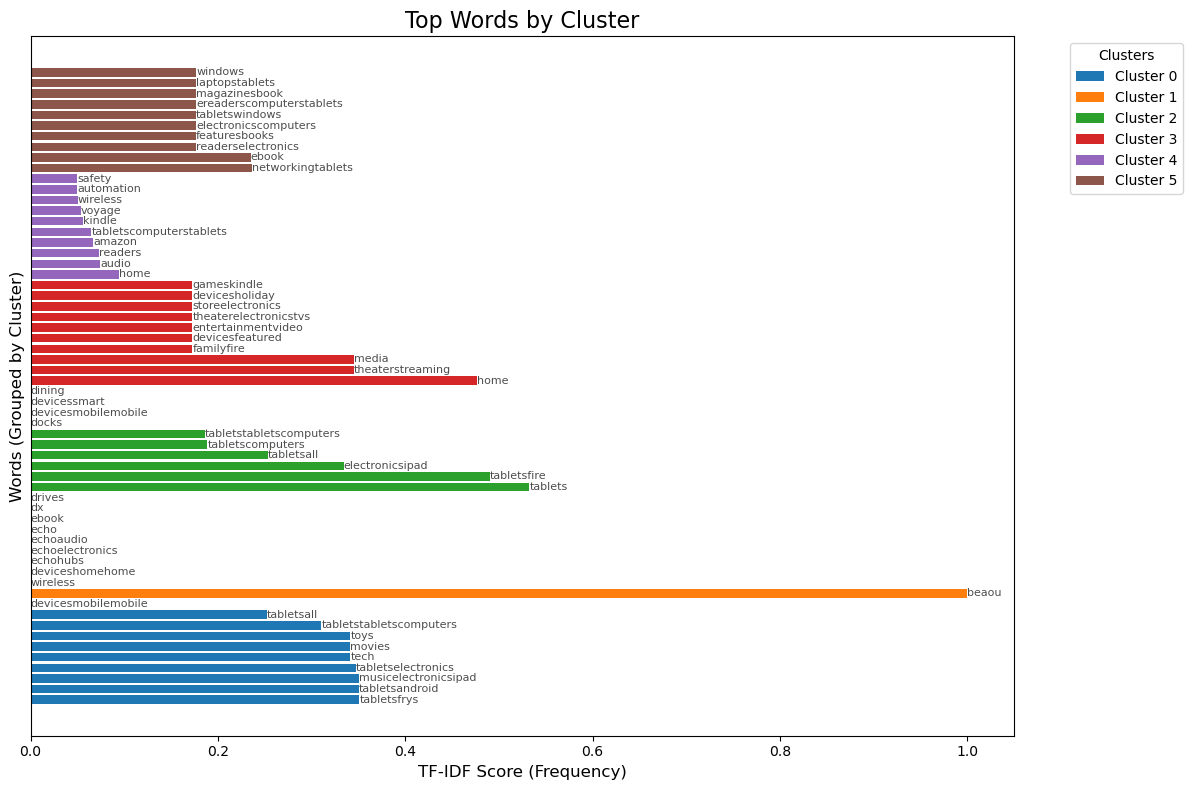

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Extract top words per cluster
def get_top_words_per_cluster(tfidf_matrix, cluster_labels, feature_names, top_n=10):
    """
    Extract the top words for each cluster based on the mean TF-IDF score.

    Args:
    - tfidf_matrix: TF-IDF matrix from vectorizer
    - cluster_labels: Cluster labels from KMeans
    - feature_names: List of feature names (words)
    - top_n: Number of top words to extract

    Returns:
    - cluster_top_words: A dictionary where keys are cluster IDs and values are lists of top words with their scores
    """
    cluster_top_words = {}
    for cluster in np.unique(cluster_labels):
        # Get indices of samples belonging to this cluster
        cluster_indices = np.where(cluster_labels == cluster)
        # Compute mean TF-IDF score for each word in the cluster
        cluster_tfidf_mean = tfidf_matrix[cluster_indices].mean(axis=0).A1
        # Get top N words for this cluster
        top_indices = cluster_tfidf_mean.argsort()[-top_n:][::-1]
        top_words = [(feature_names[i], cluster_tfidf_mean[i]) for i in top_indices]
        cluster_top_words[cluster] = top_words
    return cluster_top_words

# Step 2: Prepare TF-IDF and KMeans
# Assuming data['categories_cleaned'] contains preprocessed text for clustering
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
categories_tfidf = vectorizer.fit_transform(data['categories_cleaned'])

kmeans = KMeans(n_clusters=6, random_state=42)
data['meta_category'] = kmeans.fit_predict(categories_tfidf)

# Step 3: Get top words per cluster
feature_names = vectorizer.get_feature_names_out()
top_words_per_cluster = get_top_words_per_cluster(categories_tfidf, data['meta_category'], feature_names, top_n=10)

# Step 4: Plot word frequencies for each cluster
plt.figure(figsize=(12, 8))

for cluster, top_words in top_words_per_cluster.items():
    words, scores = zip(*top_words)
    y_positions = np.arange(len(words)) + cluster * 10  # Offset each cluster for better visibility
    plt.barh(y_positions, scores, label=f"Cluster {cluster}")
    for i, word in enumerate(words):
        plt.text(scores[i], y_positions[i], word, va='center', fontsize=8, alpha=0.7)

# Step 5: Finalize plot
plt.title("Top Words by Cluster", fontsize=16)
plt.xlabel("TF-IDF Score (Frequency)", fontsize=12)
plt.ylabel("Words (Grouped by Cluster)", fontsize=12)
plt.yticks([])  # Remove y-ticks for simplicity
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

Step 6: Group Reviews by Meta Categories

Explanation:
•	Group all reviews from the reviews.text column according to the generated meta categories.
•	Combine all reviews for each meta category into a single string.

In [8]:
# Group reviews and original categories by the generated meta categories
grouped_reviews = data.groupby('meta_category').apply(
    lambda x: pd.Series({
        'Combined Reviews': ' '.join(x['reviews.text']),
        'Original Categories': ', '.join(x['categories'].unique())
    })
)

# Convert grouped data into a DataFrame for saving
grouped_reviews_df = grouped_reviews.reset_index()
grouped_reviews_df.columns = ['Meta Category', 'Combined Reviews', 'Original Categories']

/var/folders/0v/2jlpljqd1msbtz5s_xyw4yj00000gn/T/ipykernel_89359/1932798908.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_reviews = data.groupby('meta_category').apply(


Step 7: Save Grouped Reviews to a CSV File

Explanation:
•	Save the grouped reviews into a semicolon-separated CSV file for inspection.

In [9]:
# Save grouped reviews and categories to a CSV file
output_file = 'grouped_reviews_with_categories.csv'
grouped_reviews_df.to_csv(output_file, index=False, sep=';', encoding='utf-8')
print(f"Grouped reviews with categories saved to {output_file}")

Grouped reviews with categories saved to grouped_reviews_with_categories.csv
